# Original Dual-GPU AlexNet Training & Comparison on CIFAR-10

This notebook demonstrates the training of the original **AlexNet** (2012) architecture, split across two parallel streams to simulate the original dual-GPU design. We compare the mathematical correctness and optimization convergence of **Gradience** (running on CPU) against **PyTorch** (running on GPU/CUDA if available) using a subset of the **CIFAR-10** dataset.

## 1. Imports and Setup

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

sys.path.append(os.path.abspath('..'))

from gradience.tensor import Tensor, concat
from gradience.nn.models.alexnet import OriginalAlexNet
from gradience.optim.sgd import SGD

## 2. PyTorch Dual-Stream Reference Model

In [2]:
class PtOriginalAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1_1 = nn.Conv2d(3, 48, kernel_size=11, stride=4, padding=2)
        self.conv2_1 = nn.Conv2d(48, 128, kernel_size=5, padding=2)
        self.conv3_1 = nn.Conv2d(256, 192, kernel_size=3, padding=1)
        self.conv4_1 = nn.Conv2d(192, 192, kernel_size=3, padding=1)
        self.conv5_1 = nn.Conv2d(192, 128, kernel_size=3, padding=1)

        self.conv1_2 = nn.Conv2d(3, 48, kernel_size=11, stride=4, padding=2)
        self.conv2_2 = nn.Conv2d(48, 128, kernel_size=5, padding=2)
        self.conv3_2 = nn.Conv2d(256, 192, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(192, 192, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(192, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self.fc6 = nn.Linear(256 * 6 * 6, 4096)
        self.fc7 = nn.Linear(4096, 4096)
        self.fc8 = nn.Linear(4096, num_classes)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1_1 = self.pool(self.relu(self.conv1_1(x)))
        x1_2 = self.pool(self.relu(self.conv1_2(x)))

        x2_1 = self.pool(self.relu(self.conv2_1(x1_1)))
        x2_2 = self.pool(self.relu(self.conv2_2(x1_2)))

        x2 = torch.cat((x2_1, x2_2), dim=1)

        x3_1 = self.relu(self.conv3_1(x2))
        x3_2 = self.relu(self.conv3_2(x2))

        x4_1 = self.relu(self.conv4_1(x3_1))
        x4_2 = self.relu(self.conv4_2(x3_2))

        x5_1 = self.pool(self.relu(self.conv5_1(x4_1)))
        x5_2 = self.pool(self.relu(self.conv5_2(x4_2)))

        x5 = torch.cat((x5_1, x5_2), dim=1)

        x_avg = self.avgpool(x5)
        x_flat = torch.flatten(x_avg, 1)

        x_fc6 = self.relu(self.fc6(x_flat))
        x_fc7 = self.relu(self.fc7(x_fc6))
        out = self.fc8(x_fc7)
        return out

def copy_weights_original(pt_model, gr_model):
    convs = [
        ('conv1_1', 'conv1_1'), ('conv1_2', 'conv1_2'),
        ('conv2_1', 'conv2_1'), ('conv2_2', 'conv2_2'),
        ('conv3_1', 'conv3_1'), ('conv3_2', 'conv3_2'),
        ('conv4_1', 'conv4_1'), ('conv4_2', 'conv4_2'),
        ('conv5_1', 'conv5_1'), ('conv5_2', 'conv5_2')
    ]
    for pt_name, gr_name in convs:
        pt_conv = getattr(pt_model, pt_name)
        gr_conv = getattr(gr_model, gr_name)
        gr_conv.weight.data[...] = pt_conv.weight.cpu().detach().numpy()
        if gr_conv.bias is not None:
            gr_conv.bias.data[...] = pt_conv.bias.cpu().detach().numpy()

    linears = [
        ('fc6', 'fc6'), ('fc7', 'fc7'), ('fc8', 'fc8')
    ]
    for pt_name, gr_name in linears:
        pt_linear = getattr(pt_model, pt_name)
        gr_linear = getattr(gr_model, gr_name)
        gr_linear.weight.data[...] = pt_linear.weight.cpu().detach().numpy().T
        if gr_linear.bias is not None:
            gr_linear.bias.data[...] = pt_linear.bias.cpu().detach().numpy()

## 3. CIFAR-10 Dataset Loading & Processing

In [3]:
import torchvision
import torchvision.transforms as transforms

np.random.seed(42)
torch.manual_seed(42)

num_classes = 10
batch_size = 4
height, width = 64, 64

transform = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

X_list = []
y_list = []
for idx in range(32):
    img_tensor, label = cifar_train[idx]
    X_list.append(img_tensor.numpy())
    y_list.append(label)

X_data = np.stack(X_list, axis=0).astype(np.float64)
y_data = np.array(y_list)
y_data_oh = np.eye(num_classes)[y_data]

print(f"Dataset shape: {X_data.shape}")
print(f"Labels shape:  {y_data_oh.shape}")

100.0%


Dataset shape: (32, 3, 64, 64)
Labels shape:  (32, 10)


## 4. Single Forward/Backward Pass Verification

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch Device: {device}")

gr_model = OriginalAlexNet(num_classes=num_classes)
pt_model = PtOriginalAlexNet(num_classes=num_classes).double().to(device)

copy_weights_original(pt_model, gr_model)

gr_model.eval()
pt_model.eval()

x_pt = torch.tensor(X_data[:batch_size], requires_grad=True, dtype=torch.float64, device=device)
x_gr = Tensor(X_data[:batch_size], requires_grad=True)

y_pt_oh = torch.tensor(y_data_oh[:batch_size], dtype=torch.float64, device=device)
y_gr_oh = Tensor(y_data_oh[:batch_size])

out_pt = pt_model(x_pt)
loss_pt = ((out_pt - y_pt_oh) ** 2).mean()
loss_pt.backward()

out_gr = gr_model(x_gr)
loss_gr = ((out_gr - y_gr_oh) ** 2).mean()
loss_gr.backward()

diff_logits = np.max(np.abs(out_gr.data - out_pt.cpu().detach().numpy()))
diff_loss = np.abs(loss_gr.item() - loss_pt.item())
diff_grad_in = np.max(np.abs(x_gr.grad - x_pt.grad.cpu().numpy()))

print(f"Logits Max Diff: {diff_logits:.2e}")
print(f"Loss Diff:        {diff_loss:.2e}")
print(f"Input Grad Diff:  {diff_grad_in:.2e}")

Using PyTorch Device: cuda
Logits Max Diff: 2.26e-17
Loss Diff:        1.39e-17
Input Grad Diff:  5.77e-21


## 5. Mini Training Loop Convergence Comparison

In [5]:
gr_model = OriginalAlexNet(num_classes=num_classes)
pt_model = PtOriginalAlexNet(num_classes=num_classes).double().to(device)

copy_weights_original(pt_model, gr_model)

gr_model.eval()
pt_model.eval()

lr = 0.01
gr_opt = SGD(gr_model.parameters(), lr=lr)
pt_opt = torch.optim.SGD(pt_model.parameters(), lr=lr)

gr_losses = []
pt_losses = []

for epoch in range(5):
    epoch_gr_loss = 0.0
    epoch_pt_loss = 0.0
    
    for i in range(0, len(X_data), batch_size):
        xb = X_data[i:i+batch_size]
        yb = y_data_oh[i:i+batch_size]
        
        xb_pt = torch.tensor(xb, dtype=torch.float64, device=device)
        yb_pt = torch.tensor(yb, dtype=torch.float64, device=device)
        pt_opt.zero_grad()
        out_pt_loop = pt_model(xb_pt)
        loss_pt_loop = ((out_pt_loop - yb_pt) ** 2).mean()
        loss_pt_loop.backward()
        pt_opt.step()
        epoch_pt_loss += loss_pt_loop.item()
        
        xb_gr = Tensor(xb)
        yb_gr = Tensor(yb)
        gr_opt.zero_grad()
        out_gr_loop = gr_model(xb_gr)
        loss_gr_loop = ((out_gr_loop - yb_gr) ** 2).mean()
        loss_gr_loop.backward()
        gr_opt.step()
        epoch_gr_loss += loss_gr_loop.item()
        
    gr_losses.append(epoch_gr_loss / 8.0)
    pt_losses.append(epoch_pt_loss / 8.0)
    print(f"Epoch {epoch+1} | Gradience Loss: {gr_losses[-1]:.6f} | PyTorch Loss: {pt_losses[-1]:.6f}")

Epoch 1 | Gradience Loss: 0.099269 | PyTorch Loss: 0.099269
Epoch 2 | Gradience Loss: 0.098694 | PyTorch Loss: 0.098694
Epoch 3 | Gradience Loss: 0.098148 | PyTorch Loss: 0.098148
Epoch 4 | Gradience Loss: 0.097628 | PyTorch Loss: 0.097628
Epoch 5 | Gradience Loss: 0.097133 | PyTorch Loss: 0.097133


## 6. Plot Loss Convergence

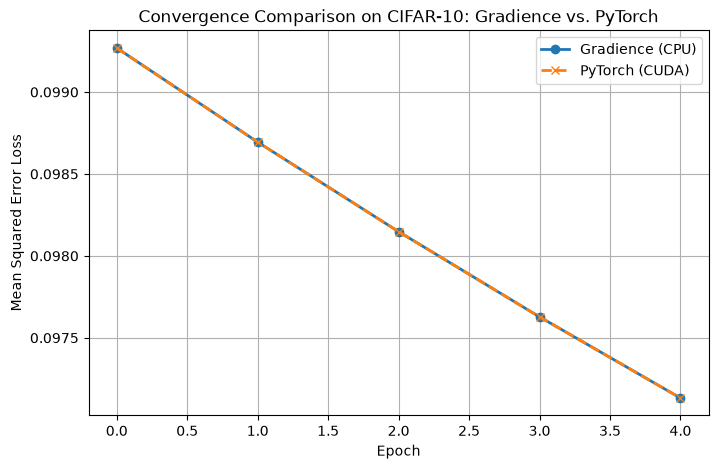

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(gr_losses, label="Gradience (CPU)", marker="o", linewidth=2)
plt.plot(pt_losses, label=f"PyTorch ({device.type.upper()})", linestyle="--", marker="x", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.title("Convergence Comparison on CIFAR-10: Gradience vs. PyTorch")
plt.legend()
plt.grid(True)
plt.savefig("alexnet_parallel_convergence.png")
plt.show()